# 02. 저장 포맷 비교 — 왜 Parquet인가?

같은 데이터를 JSON, CSV, Parquet으로 저장하면 어떤 차이가 있을까?

비교 항목:
1. **파일 크기** — 디스크를 얼마나 차지하는가
2. **쓰기 시간** — 저장하는 데 걸리는 시간
3. **읽기 시간** — 불러오는 데 걸리는 시간
4. **dtype에 따른 차이** — int64 vs int32, object vs category

## 1. 데이터 로드

하루치 parquet을 원본으로 사용합니다.

In [1]:
import time
from pathlib import Path

import pandas as pd

DATA_DIR = Path("../../data/daily_agg")
SAMPLE_FILE = DATA_DIR / "20260314.parquet"
TMP_DIR = Path("../../data/_format_bench")
TMP_DIR.mkdir(exist_ok=True)

df_raw = pd.read_parquet(SAMPLE_FILE)
print(f"Rows: {len(df_raw):,}")
print(f"\nDtypes (원본 parquet):")
print(df_raw.dtypes)
print(f"\nMemory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Rows: 1,286,115

Dtypes (원본 parquet):
actor_id    Int64
repo_id     Int64
type          str
cnt         Int64
dtype: object

Memory: 56.1 MB


## 2. DataFrame 변형 — dtype별 버전 준비

| 버전 | actor_id / repo_id | cnt | type |
|---|---|---|---|
| `raw` | int64 (BigQuery 원본) | int64 | object |
| `optimized` | Int32 | Int32 | category |
| `int32_only` | int32 | int32 | object |

세 버전을 각각 JSON, CSV, Parquet으로 저장해서 비교합니다.

In [2]:
from gharchive.transform import optimize_types

# NA 확인
na_counts = df_raw.isna().sum()
print(f"NA counts:\n{na_counts}\n")
print(f"Total rows: {len(df_raw):,}  /  NA 있는 행: {df_raw.isna().any(axis=1).sum():,}")

# raw: BigQuery 원본 그대로
df_raw_copy = df_raw.copy()

# optimized: Int32 (nullable) + category
df_optimized = optimize_types(df_raw)

# int32_only: nullable Int32 + object (category 안 씀)
df_int32 = df_raw.copy()
for col in ("actor_id", "repo_id", "cnt"):
    df_int32[col] = df_int32[col].astype("Int32")

variants = {
    "raw_int64": df_raw_copy,
    "optimized_Int32_cat": df_optimized,
    "Int32_object": df_int32,
}

for name, df in variants.items():
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name:25s}  memory: {mem:6.1f} MB  dtypes: {dict(df.dtypes)}")

NA counts:
actor_id     0
repo_id     77
type         0
cnt          0
dtype: int64

Total rows: 1,286,115  /  NA 있는 행: 77
raw_int64                  memory:   56.1 MB  dtypes: {'actor_id': Int64Dtype(), 'repo_id': Int64Dtype(), 'type': <StringDtype(na_value=nan)>, 'cnt': Int64Dtype()}
optimized_Int32_cat        memory:   19.6 MB  dtypes: {'actor_id': Int32Dtype(), 'repo_id': Int32Dtype(), 'type': CategoricalDtype(categories=['CommitCommentEvent', 'CreateEvent', 'DeleteEvent',
                  'DiscussionEvent', 'ForkEvent', 'GollumEvent',
                  'IssueCommentEvent', 'IssuesEvent', 'MemberEvent',
                  'PublicEvent', 'PullRequestEvent',
                  'PullRequestReviewCommentEvent', 'PullRequestReviewEvent',
                  'PushEvent', 'ReleaseEvent', 'WatchEvent'],
, ordered=False, categories_dtype=str), 'cnt': Int32Dtype()}
Int32_object               memory:   41.4 MB  dtypes: {'actor_id': Int32Dtype(), 'repo_id': Int32Dtype(), 'type': <StringDtype(na_v

## 3. 포맷별 저장 & 벤치마크

In [3]:
import os


def bench_write(df: pd.DataFrame, fmt: str, path: Path) -> tuple[float, int]:
    """Write df in given format, return (seconds, file_bytes)."""
    t0 = time.perf_counter()
    if fmt == "json":
        df.to_json(path, orient="records", lines=True)
    elif fmt == "csv":
        df.to_csv(path, index=False)
    elif fmt == "parquet":
        df.to_parquet(path, index=False)
    elapsed = time.perf_counter() - t0
    size = os.path.getsize(path)
    return elapsed, size


def bench_read(fmt: str, path: Path) -> float:
    """Read file in given format, return seconds."""
    t0 = time.perf_counter()
    if fmt == "json":
        pd.read_json(path, orient="records", lines=True)
    elif fmt == "csv":
        pd.read_csv(path)
    elif fmt == "parquet":
        pd.read_parquet(path)
    return time.perf_counter() - t0


FORMATS = ["json", "csv", "parquet"]
RUNS = 3  # 평균 내기 위한 반복 횟수

results = []
for var_name, df in variants.items():
    for fmt in FORMATS:
        ext = {"json": ".jsonl", "csv": ".csv", "parquet": ".parquet"}[fmt]
        path = TMP_DIR / f"{var_name}{ext}"

        # Write benchmark
        write_times = []
        for _ in range(RUNS):
            wt, file_size = bench_write(df, fmt, path)
            write_times.append(wt)

        # Read benchmark
        read_times = []
        for _ in range(RUNS):
            rt = bench_read(fmt, path)
            read_times.append(rt)

        results.append({
            "variant": var_name,
            "format": fmt,
            "file_size_MB": file_size / 1024**2,
            "write_sec": sum(write_times) / RUNS,
            "read_sec": sum(read_times) / RUNS,
        })

bench_df = pd.DataFrame(results)
print(bench_df.to_string(index=False, float_format="%.3f"))

            variant  format  file_size_MB  write_sec  read_sec
          raw_int64    json        88.066      4.608     8.923
          raw_int64     csv        41.458      4.231     1.027
          raw_int64 parquet        14.086      0.503     0.073
optimized_Int32_cat    json        88.066      4.893     6.405
optimized_Int32_cat     csv        41.458      1.738     0.532
optimized_Int32_cat parquet        11.096      0.173     0.024
       Int32_object    json        88.066      1.615     2.606
       Int32_object     csv        41.458      1.706     0.560
       Int32_object parquet        11.095      0.207     0.028


## 4. 시각화

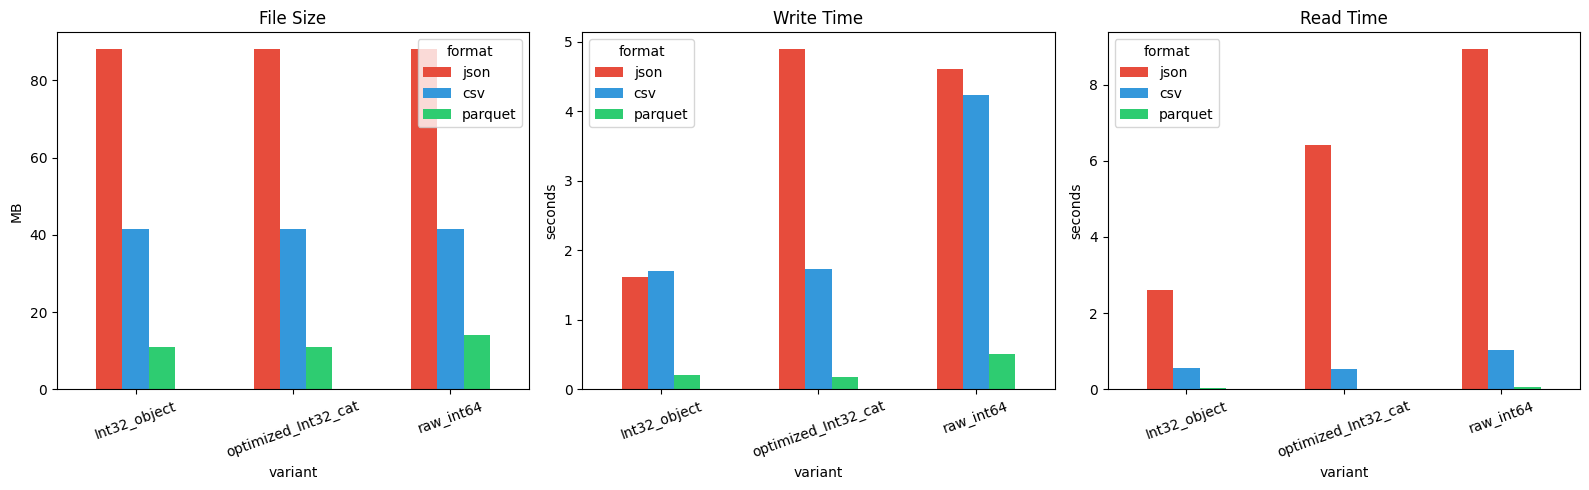

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pivot_size = bench_df.pivot(index="variant", columns="format", values="file_size_MB")
pivot_write = bench_df.pivot(index="variant", columns="format", values="write_sec")
pivot_read = bench_df.pivot(index="variant", columns="format", values="read_sec")

colors = {"json": "#e74c3c", "csv": "#3498db", "parquet": "#2ecc71"}

for ax, pivot, title, ylabel in [
    (axes[0], pivot_size, "File Size", "MB"),
    (axes[1], pivot_write, "Write Time", "seconds"),
    (axes[2], pivot_read, "Read Time", "seconds"),
]:
    pivot[FORMATS].plot.bar(ax=ax, color=[colors[f] for f in FORMATS])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="format")

plt.tight_layout()
plt.show()

## 5. Parquet 내부 — dtype에 따른 파일 크기 비교

같은 Parquet이라도 dtype을 바꾸면 파일 크기가 달라집니다.

| dtype 조합 | 기대 효과 |
|---|---|
| int64 | BigQuery 기본값. 값 범위 대비 낭비 |
| Int32 (nullable) | 4바이트 + null bitmap. NA 보존 가능 |
| Int32 + category | type 컬럼을 category로 — 메모리 절약 |
| Int32 + cnt를 Int16 | cnt는 보통 작은 값. 2바이트로 충분할 수도 |

In [5]:
# dtype 실험용 변형 생성 (모두 nullable — NA 보존)
dtype_variants = {}

# int64 (원본)
dtype_variants["int64"] = df_raw.copy()

# Int32 전체 (nullable)
d32 = df_raw.copy()
for col in ("actor_id", "repo_id", "cnt"):
    d32[col] = d32[col].astype("Int32")
dtype_variants["Int32"] = d32

# Int32 + category (optimize_types)
dtype_variants["Int32_cat"] = optimize_types(df_raw)

# Int32 + cnt를 Int16
d16 = df_raw.copy()
for col in ("actor_id", "repo_id"):
    d16[col] = d16[col].astype("Int32")
d16["cnt"] = d16["cnt"].astype("Int16")
dtype_variants["Int32_cnt16"] = d16

# 전부 Parquet으로 저장해서 크기 비교
dtype_results = []
for name, df in dtype_variants.items():
    path = TMP_DIR / f"dtype_{name}.parquet"
    df.to_parquet(path, index=False)
    size_mb = os.path.getsize(path) / 1024**2
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    dtype_results.append({
        "dtype_config": name,
        "parquet_MB": size_mb,
        "memory_MB": mem_mb,
        "dtypes": str({c: str(df[c].dtype) for c in ("actor_id", "repo_id", "cnt")}),
    })

dtype_df = pd.DataFrame(dtype_results)
print(dtype_df.to_string(index=False, float_format="%.3f"))

dtype_config  parquet_MB  memory_MB                                                    dtypes
       int64      14.086     56.145 {'actor_id': 'Int64', 'repo_id': 'Int64', 'cnt': 'Int64'}
       Int32      11.095     41.427 {'actor_id': 'Int32', 'repo_id': 'Int32', 'cnt': 'Int32'}
   Int32_cat      11.096     19.625 {'actor_id': 'Int32', 'repo_id': 'Int32', 'cnt': 'Int32'}
 Int32_cnt16      11.095     38.974 {'actor_id': 'Int32', 'repo_id': 'Int32', 'cnt': 'Int16'}


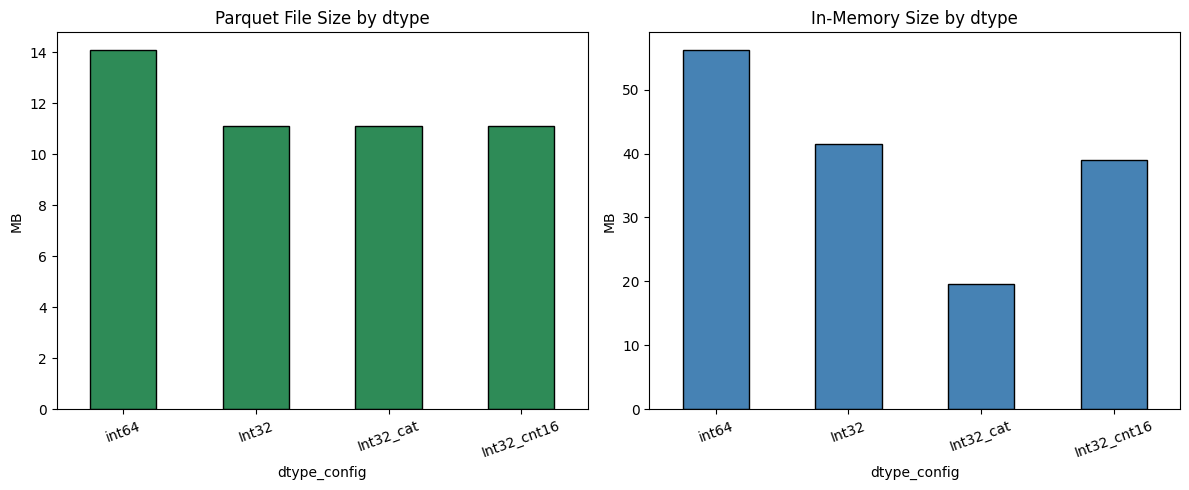

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Parquet 파일 크기
dtype_df.set_index("dtype_config")["parquet_MB"].plot.bar(
    ax=axes[0], color="seagreen", edgecolor="black"
)
axes[0].set_title("Parquet File Size by dtype")
axes[0].set_ylabel("MB")
axes[0].tick_params(axis="x", rotation=20)

# 메모리 크기
dtype_df.set_index("dtype_config")["memory_MB"].plot.bar(
    ax=axes[1], color="steelblue", edgecolor="black"
)
axes[1].set_title("In-Memory Size by dtype")
axes[1].set_ylabel("MB")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. 28일치 전체 비교

하루치가 아니라 전체 데이터(28일)에서는 차이가 더 벌어집니다.

In [7]:
# 기존 parquet 28개 합산 크기
parquet_files = sorted(DATA_DIR.glob("*.parquet"))
total_parquet_mb = sum(f.stat().st_size for f in parquet_files) / 1024**2

# 전체 로드
df_all = pd.read_parquet(DATA_DIR)
print(f"전체 {len(parquet_files)}일, {len(df_all):,} rows")
print(f"Parquet 합산: {total_parquet_mb:.1f} MB")

# JSON/CSV로 저장해서 비교
all_json = TMP_DIR / "all_28days.jsonl"
all_csv = TMP_DIR / "all_28days.csv"

df_all.to_json(all_json, orient="records", lines=True)
df_all.to_csv(all_csv, index=False)

json_mb = os.path.getsize(all_json) / 1024**2
csv_mb = os.path.getsize(all_csv) / 1024**2

print(f"\n28일치 포맷별 파일 크기:")
print(f"  JSON:    {json_mb:7.1f} MB")
print(f"  CSV:     {csv_mb:7.1f} MB")
print(f"  Parquet: {total_parquet_mb:7.1f} MB")
print(f"\nParquet은 JSON 대비 {json_mb / total_parquet_mb:.1f}배, CSV 대비 {csv_mb / total_parquet_mb:.1f}배 작음")

전체 28일, 38,820,324 rows
Parquet 합산: 424.2 MB



28일치 포맷별 파일 크기:
  JSON:     2659.4 MB
  CSV:      1252.5 MB
  Parquet:   424.2 MB

Parquet은 JSON 대비 6.3배, CSV 대비 3.0배 작음


## 7. 정리

**포맷 비교 결론:**
- **파일 크기**: Parquet ≪ CSV < JSON — 열 기반 압축의 힘
- **읽기 속도**: Parquet이 가장 빠름 (바이너리 + 메타데이터 내장)
- **쓰기 속도**: CSV가 단순해서 빠를 수 있지만, 읽기 비용까지 합치면 Parquet이 유리

**dtype 비교 결론:**
- int64 → int32만 해도 Parquet 파일 크기와 메모리 모두 줄어듦
- Parquet은 내부적으로 컬럼별 인코딩(dictionary, delta 등)을 적용하므로 dtype 효과가 CSV만큼 극적이진 않을 수 있음
- cnt처럼 값 범위가 작은 컬럼은 int16으로 더 줄일 수 있음

In [8]:
# 벤치마크 임시 파일 정리
import shutil

shutil.rmtree(TMP_DIR, ignore_errors=True)
print("임시 파일 삭제 완료")

임시 파일 삭제 완료
